<a href="https://colab.research.google.com/github/rcthiago/Getting-and-Cleaning-Data-Project/blob/master/PCA_step_by_step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Passo 1
**Centralizar os dados**

A centralização dos dados significa subtrair a média de cada variável, o que garante que os dados estejam centrados na origem.

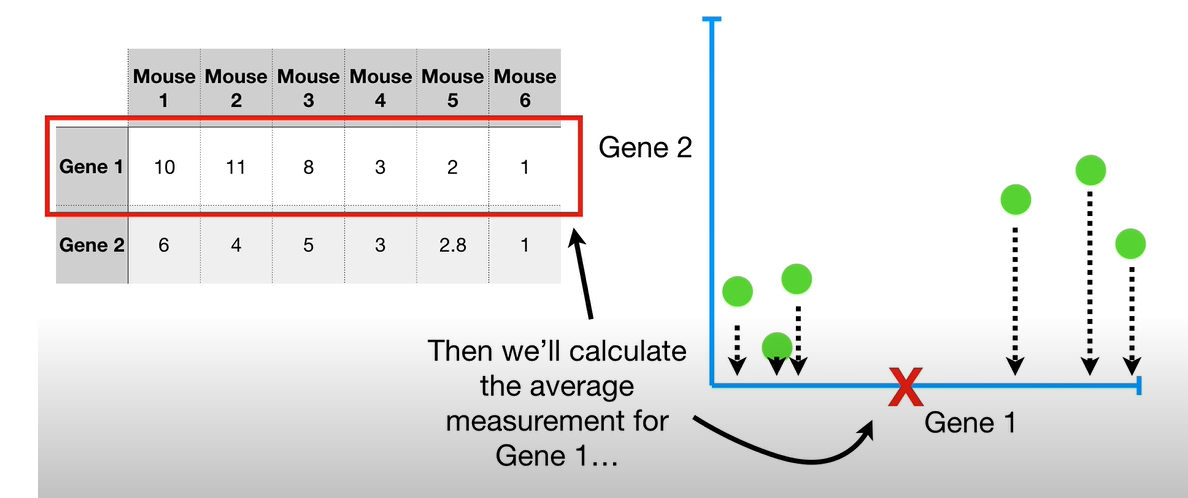

In [1]:
import numpy as np
import matplotlib.pyplot as plt

gene1 = [10, 11, 8, 3, 2, 1]
gene2 = [6, 4, 5, 3, 2.8, 1]
# 1. Carregar os dados
X = np.array([gene1, gene2]).T  # Matriz de dados transposta


In [2]:
# Cálculo das médias de cada coluna (Gene 1 e Gene 2)
mean_values = np.mean(X, axis=0)

#Médias
print(f"Média Gene 1: {np.mean(gene1):.2f}) ")
print(f"Média Gene 2: {np.mean(gene2):.2f}) ")


# Criação de uma matriz que mostre as operações
X_operations = [[f"{X[i, 0]} - {mean_values[0]:.2f}", f"{X[i, 1]} - {mean_values[1]:.2f} "] for i in range(X.shape[0])]

# Imprimir as operações
print("------------------Passo 1---------------")
X_operations


Média Gene 1: 5.83) 
Média Gene 2: 3.63) 
------------------Passo 1---------------


[['10.0 - 5.83', '6.0 - 3.63 '],
 ['11.0 - 5.83', '4.0 - 3.63 '],
 ['8.0 - 5.83', '5.0 - 3.63 '],
 ['3.0 - 5.83', '3.0 - 3.63 '],
 ['2.0 - 5.83', '2.8 - 3.63 '],
 ['1.0 - 5.83', '1.0 - 3.63 ']]

In [5]:
print("--------Resultado Passo 1---------------")
X_meaned = [[X[i, 0] - mean_values[0], X[i, 1] - mean_values[1]] for i in range(X.shape[0])]
print(X_meaned)

--------Resultado Passo 1---------------
[[4.166666666666667, 2.3666666666666667], [5.166666666666667, 0.3666666666666667], [2.166666666666667, 1.3666666666666667], [-2.833333333333333, -0.6333333333333333], [-3.833333333333333, -0.8333333333333335], [-4.833333333333333, -2.6333333333333333]]


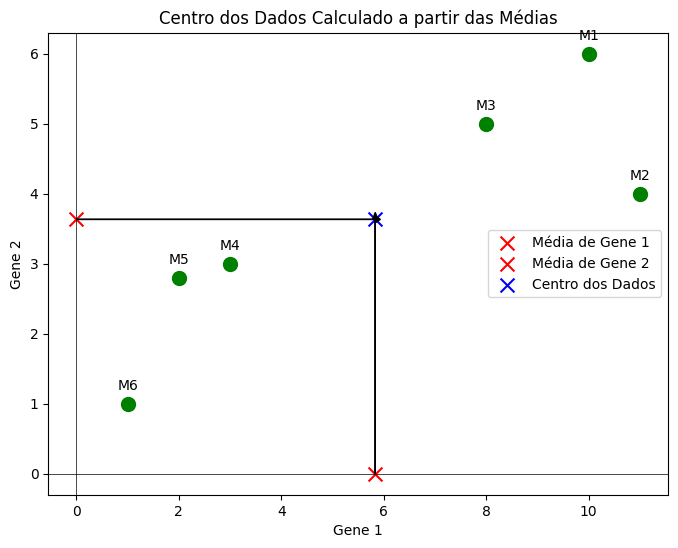

In [4]:
# Plotar os dados originais com labels, conexão entre a média de Gene 1 e Gene 2, e legendas
plt.figure(figsize=(8, 6))

# Plotar os dados originais como bolinhas verdes
plt.scatter(X[:, 0], X[:, 1], color='green', s=100)

# Adicionar o rótulo M1, M2, etc. para cada ponto
labels = ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']
for i in range(X.shape[0]):
    plt.text(X[i, 0], X[i, 1] + 0.2, labels[i], color='black', ha='center')

# Cálculo das médias de Gene 1 e Gene 2
mean_gene1 = np.mean(X[:, 0])
mean_gene2 = np.mean(X[:, 1])

# Plotar o X vermelho nas médias de Gene 1 e Gene 2, com as legendas
plt.scatter(mean_gene1, 0, color='red', marker='x', s=100, label='Média de Gene 1')
plt.scatter(0, mean_gene2, color='red', marker='x', s=100, label='Média de Gene 2')

# Plotar o centro (média de ambos os genes) com a legenda
plt.scatter(mean_gene1, mean_gene2, color='blue', marker='x', s=100, label='Centro dos Dados')

# Plotar as setas conectando as médias
plt.arrow(mean_gene1, 0, 0, mean_gene2, head_width=0.1, head_length=0.1, fc='black', ec='black')
plt.arrow(0, mean_gene2, mean_gene1, 0, head_width=0.1, head_length=0.1, fc='black', ec='black')

# Ajustes no gráfico
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Gene 1')
plt.ylabel('Gene 2')
plt.title('Centro dos Dados Calculado a partir das Médias')
plt.legend()

# Remover as grades
plt.grid(False)

plt.show()


# Passo 2 - Calcular a matriz de covariância

**O que é a Matriz de Covariância?**

A covariância mede a forma como **duas variáveis variam juntas**. Se as duas variáveis aumentam ou diminuem juntas (ou seja, são positivamente correlacionadas), a covariância será positiva. Se uma variável aumenta enquanto a outra diminui (ou seja, são negativamente correlacionadas), a covariância será negativa. Se não houver uma relação clara entre as variáveis, a covariância será próxima de zero.

A matriz de covariância é uma tabela que mostra as covariâncias entre cada par de variáveis (neste caso, entre os genes).


**Estrutura da Matriz de Covariância**

A matriz de covariância é uma matriz simétrica, onde:

O elemento na posição
(
𝑖
,
𝑗
)
(i,j) da matriz é a covariância entre a variável
𝑖
i e a variável
𝑗
j.


O elemento na diagonal
(
𝑖
,
𝑖
)
(i,i) é a variância da variável
𝑖
i, que indica o quanto essa variável varia sozinha.


**No nosso caso:**
A matriz de covariância é calculada para os genes (Gene 1 e Gene 2) nos dados centralizados. Como os dados foram centralizados, o valor médio de cada variável já foi removido.


O parâmetro rowvar=False no np.cov especifica que as variáveis estão organizadas por colunas no array X_meaned.


**Exemplo de uma matriz de covariância (hipotética) entre dois genes:**

cov_matrix = \begin{bmatrix} \text{Var}(Gene 1) & \text{Cov}(Gene 1, Gene 2) \\ \text{Cov}(Gene 1, Gene 2) & \text{Var}(Gene 2) \end{bmatrix}

**O que está sendo feito:**

**Centralizar os dados:**
  
  Primeiro, subtraímos a média de cada variável, o que "alinha" os dados em torno da origem.

**Calcular as covariâncias:**

Em seguida, estamos verificando como essas variáveis variam em relação umas às outras, resultando na matriz de covariância. A **diagonal** contém a variância de cada gene, enquanto os elementos fora da diagonal são as covariâncias entre os genes.
Essa matriz será usada para identificar a direção de maior variância nos dados (os componentes principais), que é a base para a Análise de Componentes Principais (PCA).

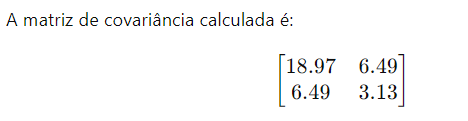

In [6]:
# 3. Calcular a matriz de covariância
cov_matrix = np.cov(X_meaned, rowvar=False)
print(cov_matrix)

[[18.96666667  6.48666667]
 [ 6.48666667  3.12666667]]


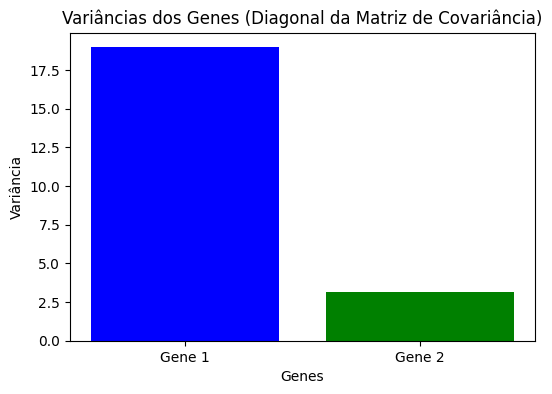

In [7]:
# Extrair os elementos da diagonal da matriz de covariância (variâncias de cada gene)
variances = np.diag(cov_matrix)

# Plotar as variâncias (diagonal da matriz de covariância)
plt.figure(figsize=(6, 4))
plt.bar(['Gene 1', 'Gene 2'], variances, color=['blue', 'green'])

# Ajustes no gráfico
plt.xlabel('Genes')
plt.ylabel('Variância')
plt.title('Variâncias dos Genes (Diagonal da Matriz de Covariância)')
plt.show()


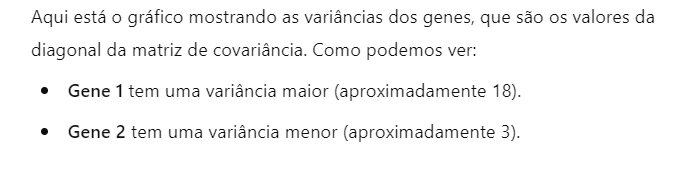

# `Passo 3` - Calcular os autovalores e autovetores

⚫ **O que são Autovalores e Autovetores?**

Autovetores são direções no espaço de variáveis onde os dados variam mais.
Autovalores indicam a magnitude dessa variação nas direções dos autovetores. Cada autovalor está associado a um autovetor correspondente.

⚫ **Em termos simples:**

Um autovetor aponta para a direção de maior variação nos dados.
O autovalor associado ao autovetor nos diz quanto os dados variam ao longo dessa direção.

🔼 **O que está acontecendo nesse passo?**

Quando aplicamos a função *np.linalg.eig(cov_matrix)*:

**Entrada:** A função recebe a matriz de covariância dos dados.

**Saída:**

*eigenvalues*: Os autovalores que indicam a quantidade de variância capturada por cada autovetor (direção).

*eigenvectors:* Os autovetores que representam as direções dos novos eixos (os componentes principais no PCA).


⚫ **Por que isso é importante no PCA?**

Autovetores determinam as direções dos componentes principais.

Cada autovetor aponta para uma direção em que os dados variam.
O primeiro autovetor (associado ao maior autovalor) aponta para a direção onde a variância nos dados é maior — ou seja, o primeiro componente principal (PCA1).
Autovalores determinam a importância de cada componente.

Autovalores maiores significam que mais variância dos dados é capturada ao longo daquela direção (componente principal).

**O primeiro componente principal (PCA1) é o que tem o maior autovalor e captura a maior parte da variância nos dados.**

**O segundo componente principal (PCA2) é perpendicular ao primeiro e captura a próxima maior variância, e assim por diante.**

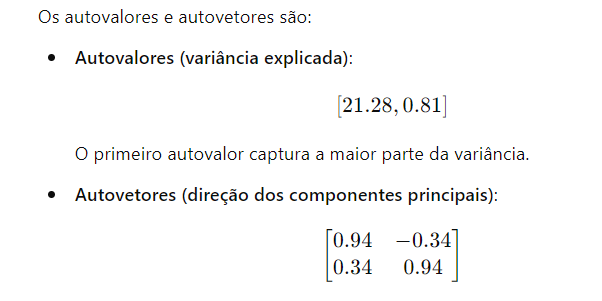

In [ ]:
# 4. Calcular autovalores e autovetores
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
eigenvectors

array([[ 0.94171069, -0.33642381],
       [ 0.33642381,  0.94171069]])

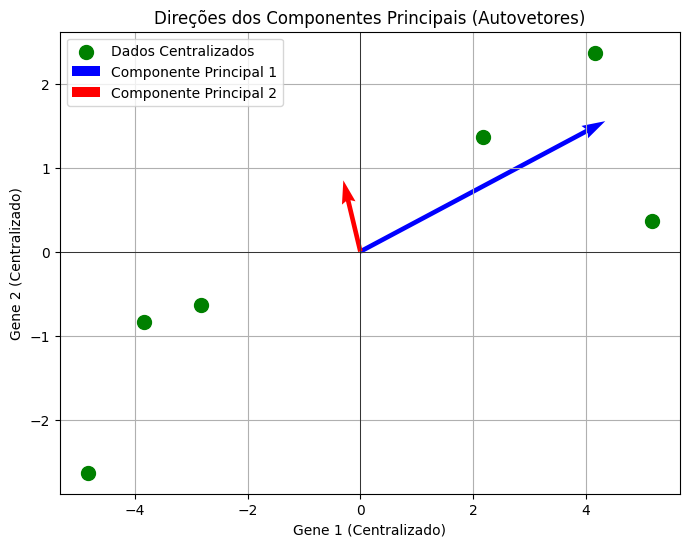

In [ ]:
# Plotar os dados originais com as direções dos componentes principais (autovetores)
plt.figure(figsize=(8, 6))

# Plotar os dados centralizados
plt.scatter(X_meaned[:, 0], X_meaned[:, 1], color='green', label='Dados Centralizados', s=100)

# Traçar as retas correspondentes aos autovetores (componentes principais)
origin = [0, 0]  # Origem para desenhar as direções
for i in range(len(eigenvalues)):
    # Escalar o autovetor pelo autovalor para aumentar a visualização
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i])
    plt.quiver(*origin, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=['blue', 'red'][i], label=f'Componente Principal {i+1}')

# Ajustes no gráfico
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Gene 1 (Centralizado)')
plt.ylabel('Gene 2 (Centralizado)')
plt.title('Direções dos Componentes Principais (Autovetores)')
plt.grid(True)
plt.legend()

plt.show()


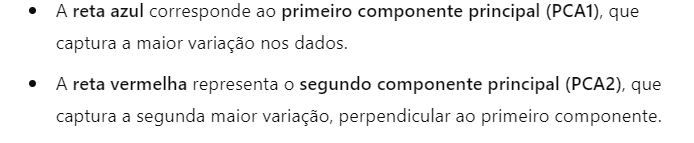

# Passo 4 - Ordenação dos Autovalores e Seleção dos Componentes

**Por que ordenamos em ordem decrescente?**

No PCA, o objetivo é capturar o máximo de variância possível nos primeiros componentes. Ao ordenar os autovalores em ordem decrescente, estamos garantindo que:

O **primeiro componente principal** (PCA1) é aquele que captura a maior quantidade de variância.


O **segundo componente principal** (PCA2) é aquele que captura a segunda maior quantidade de variância, e assim por diante.
Isso significa que o **PCA1** (componente associado ao maior autovalor) terá mais "*peso*" na descrição dos dados, enquanto os componentes com autovalores menores (PCA2, PCA3, etc.) são menos importantes, pois capturam menos variância.

Os autovalores já estão ordenados em ordem decrescente, sendo o primeiro autovalor associado ao maior componente principal.

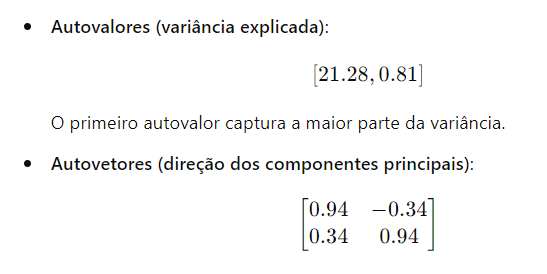

In [ ]:
# 5. Ordenação dos autovalores e autovetores
sorted_index = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_index]
sorted_eigenvectors = eigenvectors[:, sorted_index]

In [ ]:
sorted_eigenvectors

array([[ 0.94171069, -0.33642381],
       [ 0.33642381,  0.94171069]])

# Passo 5 - Transformação dos Dados

Esse passo é onde o PCA **realmente transforma os dado**s, convertendo-os para um novo espaço de variáveis (os componentes principais).

💡 **Vou explicar em mais detalhes.:**

*O que significa "transformar os dados"?*

Quando dizemos que os dados são projetados no espaço dos componentes principais, significa que estamos recalculando os dados originais para expressá-los em termos dos novos eixos (os componentes principais) ao invés dos eixos originais (variáveis originais).

**Vamos ver o que isso envolve:**

1.**O que são os componentes principais?**

Depois de calcularmos os autovetores no passo anterior, esses autovetores se tornam os novos eixos do sistema de coordenadas.

Cada autovetor define uma direção (um componente principal), e as direções dos componentes principais são aquelas onde os dados têm mais variação.

2.**Projeção dos Dados**

Agora, vamos projetar os dados no novo espaço definido pelos componentes principais.

⚠️ **O que isso significa?**

No espaço original, os dados eram representados em termos das variáveis originais (por exemplo, "Gene 1" e "Gene 2").]

Após o PCA, os dados são reescritos em termos das direções de máxima variância (os componentes principais), que são combinações lineares das variáveis originais.

A projeção dos dados é o processo de pegar os dados originais e calcular a posição deles nos novos eixos (os componentes principais). Ou seja, estamos redescrevendo os dados no novo sistema de coordenadas.


**Como isso é feito?**

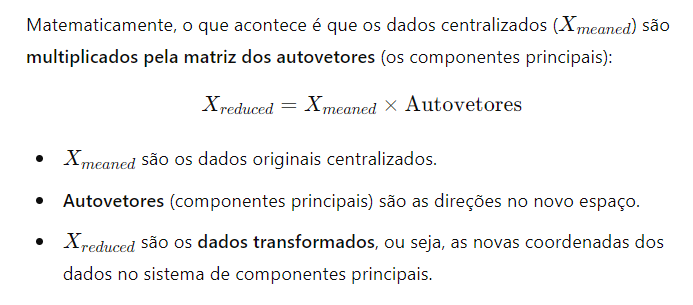

3. **Componentes não correlacionados**

Uma das vantagens dessa transformação é que os novos componentes principais são **não correlacionados.** Isso significa que, ao longo do **PCA1** (primeiro componente principal), os dados não variam mais na direção de **PCA2** (segundo componente). Essa propriedade de independência entre os componentes torna o PCA útil para simplificar e interpretar os dados.


4. **Escolha do número de componentes**

Após transformar os dados, podemos escolher quantos componentes manter, dependendo de quanta variância queremos preservar:


⚫ **Primeiros componentes** capturam a maior parte da variância dos dados.

⚫ **Componentes subsequentes** capturam menos variância, então podemos descartá-los se eles não contribuem muito.

**Por exemplo:**

Se queremos capturar 95% da variância dos dados, podemos manter apenas os primeiros componentes que explicam essa porcentagem, descartando os outros, o que nos ajuda a reduzir a dimensionalidade dos dados.


**Resumo do passo:**
No passo de transformação dos dados, pegamos os dados originais e projetamos eles no novo espaço dos componentes principais, resultando em um novo conjunto de variáveis (componentes) que são combinações das variáveis originais.

Esse novo conjunto de variáveis é não correlacionado, o que simplifica a análise e permite a redução de dimensionalidade mantendo a maior parte da variância dos dados.

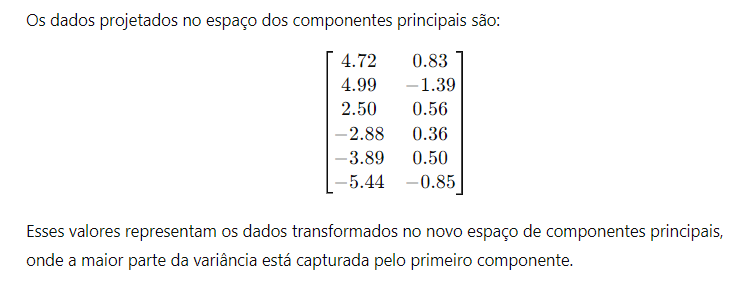

In [ ]:
# 6. Transformação dos dados (Projeção)
X_reduced = np.dot(X_meaned, sorted_eigenvectors)

In [ ]:
X_reduced

array([[ 4.71999755,  0.82694943],
       [ 4.98886062, -1.39289575],
       [ 2.50015236,  0.55808636],
       [-2.8812487 ,  0.35678402],
       [-3.89024415,  0.50486569],
       [-5.43751769, -0.85378974]])

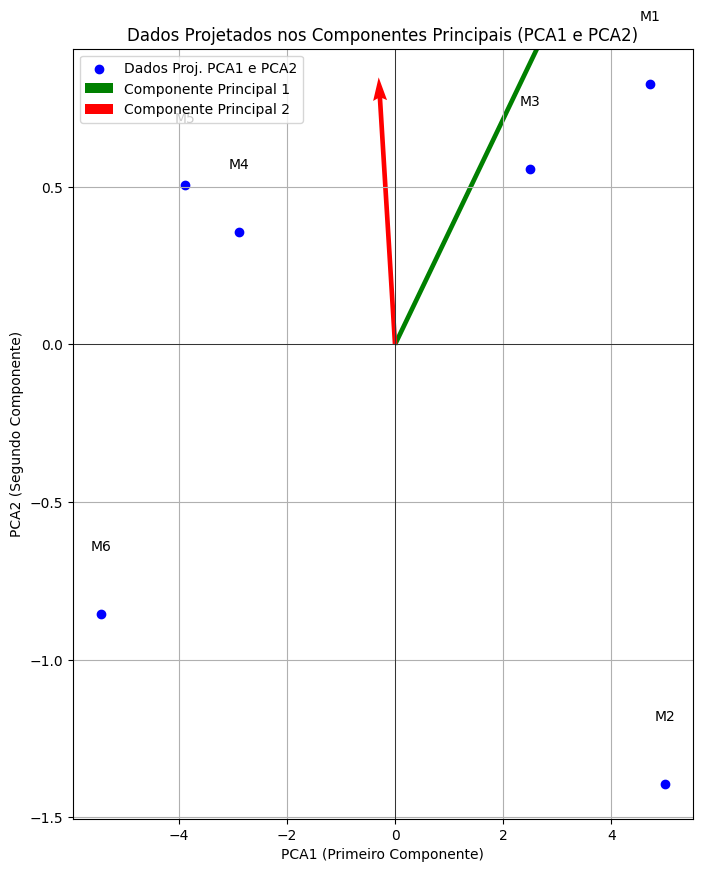

In [ ]:
# Plotar os dados transformados (após a projeção nos componentes principais)
plt.figure(figsize=(8, 10))

# Plotar os dados no espaço transformado (X_reduced)
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], color='blue', label='Dados Proj. PCA1 e PCA2')

# Adicionar rótulos para cada ponto
for i in range(X_reduced.shape[0]):
    plt.text(X_reduced[i, 0], X_reduced[i, 1] + 0.2, labels[i], color='black', ha='center')

# Traçar os autovetores como os novos eixos (PCA1 e PCA2)
origin = [0, 0]  # Origem do novo sistema de coordenadas
for i in range(len(sorted_eigenvectors)):
    vec = sorted_eigenvectors[:, i] * np.sqrt(sorted_eigenvalues[i])
    plt.quiver(*origin, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=['green', 'red'][i], label=f'Componente Principal {i+1}')

# Ajustes no gráfico
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('PCA1 (Primeiro Componente)')
plt.ylabel('PCA2 (Segundo Componente)')
plt.title('Dados Projetados nos Componentes Principais (PCA1 e PCA2)')
plt.grid(True)
plt.legend()

plt.show()

# Resultado

Se tivermos que escolher as três amostras (M) que mais capturam a variância dos dados, devemos nos concentrar nas amostras que têm os maiores valores absolutos em PCA1, já que o **PCA1 captura a maior parte da variância dos dados.**

No gráfico que você forneceu, podemos observar diretamente que as três amostras com os maiores valores em PCA1 são:
**M1 M2 M3**

Essas amostras têm os maiores valores absolutos ao longo do eixo PCA1, o que significa que elas capturam a maior parte da variância dos dados.

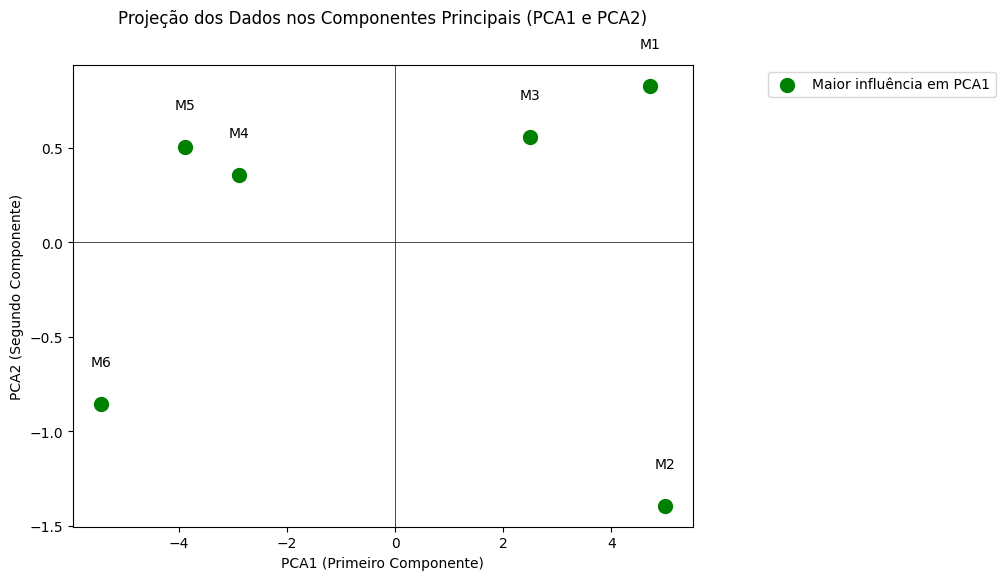

In [ ]:
# Exibir os resultados
cov_matrix, sorted_eigenvalues, sorted_eigenvectors, X_reduced

# Plotar a projeção dos dados nos componentes principais (PCA1 e PCA2) com mais espaçamento no título e na legenda
plt.figure(figsize=(8, 6))

# Destacar os valores da PCA1 e PCA2 usando cores diferentes
for i in range(X_reduced.shape[0]):
    if abs(X_reduced[i, 0]) > abs(X_reduced[i, 1]):
        # Amostras influentes em PCA1 (com maior valor absoluto)
        plt.scatter(X_reduced[i, 0], X_reduced[i, 1], color='green', label='Maior influência em PCA1' if i == 0 else "", s=100)
    else:
        # Amostras influentes em PCA2 (com maior valor absoluto)
        plt.scatter(X_reduced[i, 0], X_reduced[i, 1], color='red', label='Maior influência em PCA2' if i == 0 else "", s=100)

# Adicionar rótulos para cada ponto
for i in range(X_reduced.shape[0]):
    plt.text(X_reduced[i, 0], X_reduced[i, 1] + 0.2, labels[i], color='black', ha='center')

# Ajustes no gráfico
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('PCA1 (Primeiro Componente)')
plt.ylabel('PCA2 (Segundo Componente)')

# Ajustar o espaçamento do título para que fique mais distante do gráfico
plt.title('Projeção dos Dados nos Componentes Principais (PCA1 e PCA2)', pad=30)  # Aumentar o pad do título

# Ajustar a posição da legenda para que fique bem distante do gráfico
plt.legend(loc='upper right', bbox_to_anchor=(1.5, 1))  # Ajustar o espaçamento da legenda

plt.grid(False)
plt.show()


# Usando sklearn

In [ ]:
# Vamos usar a biblioteca sklearn para realizar o PCA
from sklearn.decomposition import PCA

# Definir o modelo de PCA para dois componentes
pca = PCA(n_components=2)

# Ajustar o modelo PCA e transformar os dados centralizados
X_pca = pca.fit_transform(X_meaned)

# Exibir os componentes principais gerados pelo PCA da sklearn
X_pca

array([[ 4.71999755,  0.82694943],
       [ 4.98886062, -1.39289575],
       [ 2.50015236,  0.55808636],
       [-2.8812487 ,  0.35678402],
       [-3.89024415,  0.50486569],
       [-5.43751769, -0.85378974]])

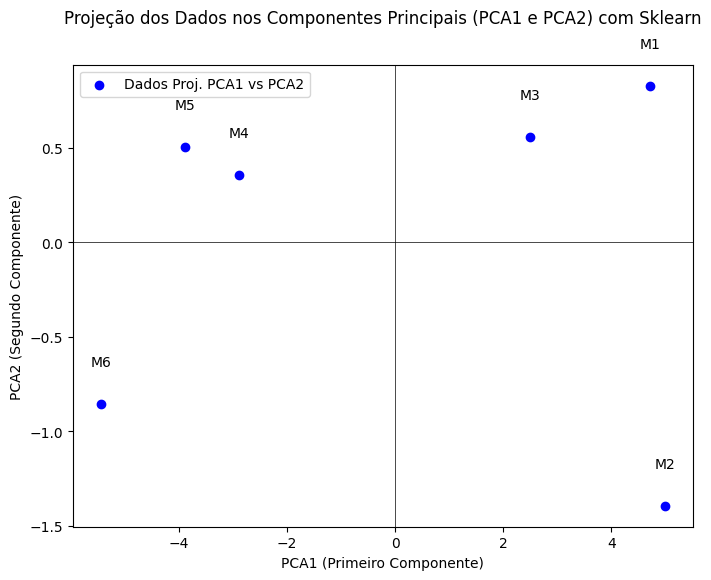

In [ ]:
# Plotando o resultado usando sklearn PCA
plt.figure(figsize=(8, 6))

# Plotar os dados projetados pelo PCA do sklearn
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='Dados Proj. PCA1 vs PCA2')

# Adicionar rótulos para cada ponto
for i in range(X_pca.shape[0]):
    plt.text(X_pca[i, 0], X_pca[i, 1] + 0.2, labels[i], color='black', ha='center')

# Ajustes no gráfico
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('PCA1 (Primeiro Componente)')
plt.ylabel('PCA2 (Segundo Componente)')
plt.title('Projeção dos Dados nos Componentes Principais (PCA1 e PCA2) com Sklearn', pad=30)
plt.grid(False)
plt.legend()

plt.show()